# analayze DTA scoring output for evenly sampled population

#### import packages

In [27]:
import os

import itertools
from itertools import combinations

import pandas as pd 
import csv 
import numpy as np 

import matplotlib.pyplot as plt 
%matplotlib inline 

import seaborn as sns 

In [28]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

#### import scores

In [21]:
dir = "scores/" 
scores = sorted(os.listdir(dir))[1:]

In [22]:
scores[0:5]

['control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-3_seed155.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-3_seed179.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-3_seed31.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-3_seed55.csv',
 'control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-3_seed79.csv']

In [23]:
list = [score.split("_") for score in scores]
type = [item[0] for item in list]
pm = [item[3][2:] for item in list]
mr = [item[4][2:] for item in list]
seed = [item[5][4:-4] for item in list]

In [24]:
runs = pd.DataFrame(scores, columns= ["path"])
runs['type'] = type
runs['pm'] = pm 
runs['mr'] = mr 
runs['seed'] = seed 
runs['path'] = "scores/" + runs['path']
## find unique combinations of pm/mr (i.e. identify reps) 
runs['rep'] = runs.groupby(['type', 'pm', 'mr']).cumcount() + 1

In [25]:
runs

,path,type,pm,mr,seed,rep
0,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-3,155,1
1,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-3,179,2
2,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-3,31,3
3,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-3,55,4
4,scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.00...,control,1.000e-1,1.000e-3,79,5
...,...,...,...,...,...,...
363,scores/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-5...,sim,3.000e-1,5.000e-5,158,1
364,scores/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-5...,sim,3.000e-1,5.000e-5,182,2
365,scores/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-5...,sim,3.000e-1,5.000e-5,34,3
366,scores/sim_ss_mu2.500e-8_pm3.000e-1_mr5.000e-5...,sim,3.000e-1,5.000e-5,58,4


In [26]:
combos = runs[['pm', 'mr']].drop_duplicates()

In [9]:
# pd.read_csv('scores/control_ss_mu2.500e-8_pm1.000e-1_mr1.000e-4_seed37.csv')
# pd.read_csv('scores/sim_ss_mu2.500e-8_pm1.000e-1_mr1.000e-4_seed37.csv')

In [10]:
# pd.read_csv('scores/inf_ss_mu2.500e-8_pm1.000e-1_mr1.000e-4_seed37.csv')

In [11]:
# read in dataframes from dir "scores/" 
# add columns "pm" "mr" "seed" according to path 
# pd.merge to larger dataframe 

#df runs has cols path type pm mr seed rep 
# groupby columns pm/mr 
# read in csvs for all paths within a group
# add cols to csvs with 'pm' and 'mr' and 'seed' 
# groupby cols ['node_height_sim', 'score', 'type'] 
# perform binomial logistic glm predicting 'score' as function of 'node_height_sim' across dense grid of "node_height_sim" from 0 to node_height_sim.max()

## combine data and perform glm

In [12]:
# merge data from each 
data = [] 
for (pm_val, mr_val), group in runs.groupby(['pm', 'mr']):
    for _, row in group.iterrows():
        csv_df = pd.read_csv(row['path'])
        csv_df['pm'] = pm_val
        csv_df['mr'] = mr_val
        csv_df['seed'] = row['seed']
        csv_df['type'] = row['type']
        data.append(csv_df)

combined_df = pd.concat(data, ignore_index=True)

combined_df['pm'] = pd.to_numeric(combined_df['pm'])
combined_df['mr'] = pd.to_numeric(combined_df['mr'])

In [13]:
# merge data from each 
data = [] 
for (pm_val, mr_val), group in runs.groupby(['pm', 'mr']):
    for _, row in group.iterrows():
        csv_df = pd.read_csv(row['path'])
        csv_df['pm'] = pm_val
        csv_df['mr'] = mr_val
        csv_df['seed'] = row['seed']
        csv_df['type'] = row['type']
        data.append(csv_df)

combined_df = pd.concat(data, ignore_index=True)

combined_df['pm'] = pd.to_numeric(combined_df['pm'])
combined_df['mr'] = pd.to_numeric(combined_df['mr'])

# downsample
bins = 15

combined_df['node_height_log'] = np.log(combined_df['node_height_sim'])
# combined_df['nh_bin'] = combined_df.groupby(['seed', 'pm', 'mr', 'bin', 'position', 'type'])['node_height_log'].transform(
#     lambda x: pd.cut(x, bins=bins, labels=False))
combined_df['nh_bin'] = pd.cut(combined_df['node_height_log'], bins=bins, labels=False)


downsample_cols = ['seed', 'pm', 'mr', 'bin', 'position', 'type', 'nh_bin']
downsampled_df = (
    combined_df.groupby(downsample_cols, group_keys=False, dropna=False)
    .apply(lambda x: x.sample(n=min(len(x), 3)))
    .reset_index(drop=True)
)

# binomial glm 
results_dict = {}

for (type_val, pm_val, mr_val), type_df in downsampled_df.groupby(['type', 'pm', 'mr']):
    if len(type_df['score'].unique()) < 2:
        continue
        
    model = smf.glm(formula="score ~ node_height_sim", data=type_df, family=sm.families.Binomial())
    fitted_model = model.fit()
    
    max_sim = type_df['node_height_sim'].max()
    min_sim = max(type_df['node_height_sim'].min(), 1e-4)
    
    dense_grid = pd.DataFrame({
        'node_height_sim': np.logspace(np.log10(min_sim), np.log10(max_sim), 5000)
    })
    dense_grid['predicted_score'] = fitted_model.predict(dense_grid)
    
    # store vals in dic
    results_dict[(type_val, pm_val, mr_val)] = {
        'model': fitted_model,
        'predictions': dense_grid
    }



## plot raw data + predicted scores

In [14]:
# plot
color_palette = {
    "sim": "#F2AD00",
    "inf": "#00A08A",
    "ctrl": "grey"
}

# grid 
pm_vals = sorted(downsampled_df['pm'].unique()) # 4 rows
mr_vals = sorted(downsampled_df['mr'].unique())  # 6 columns

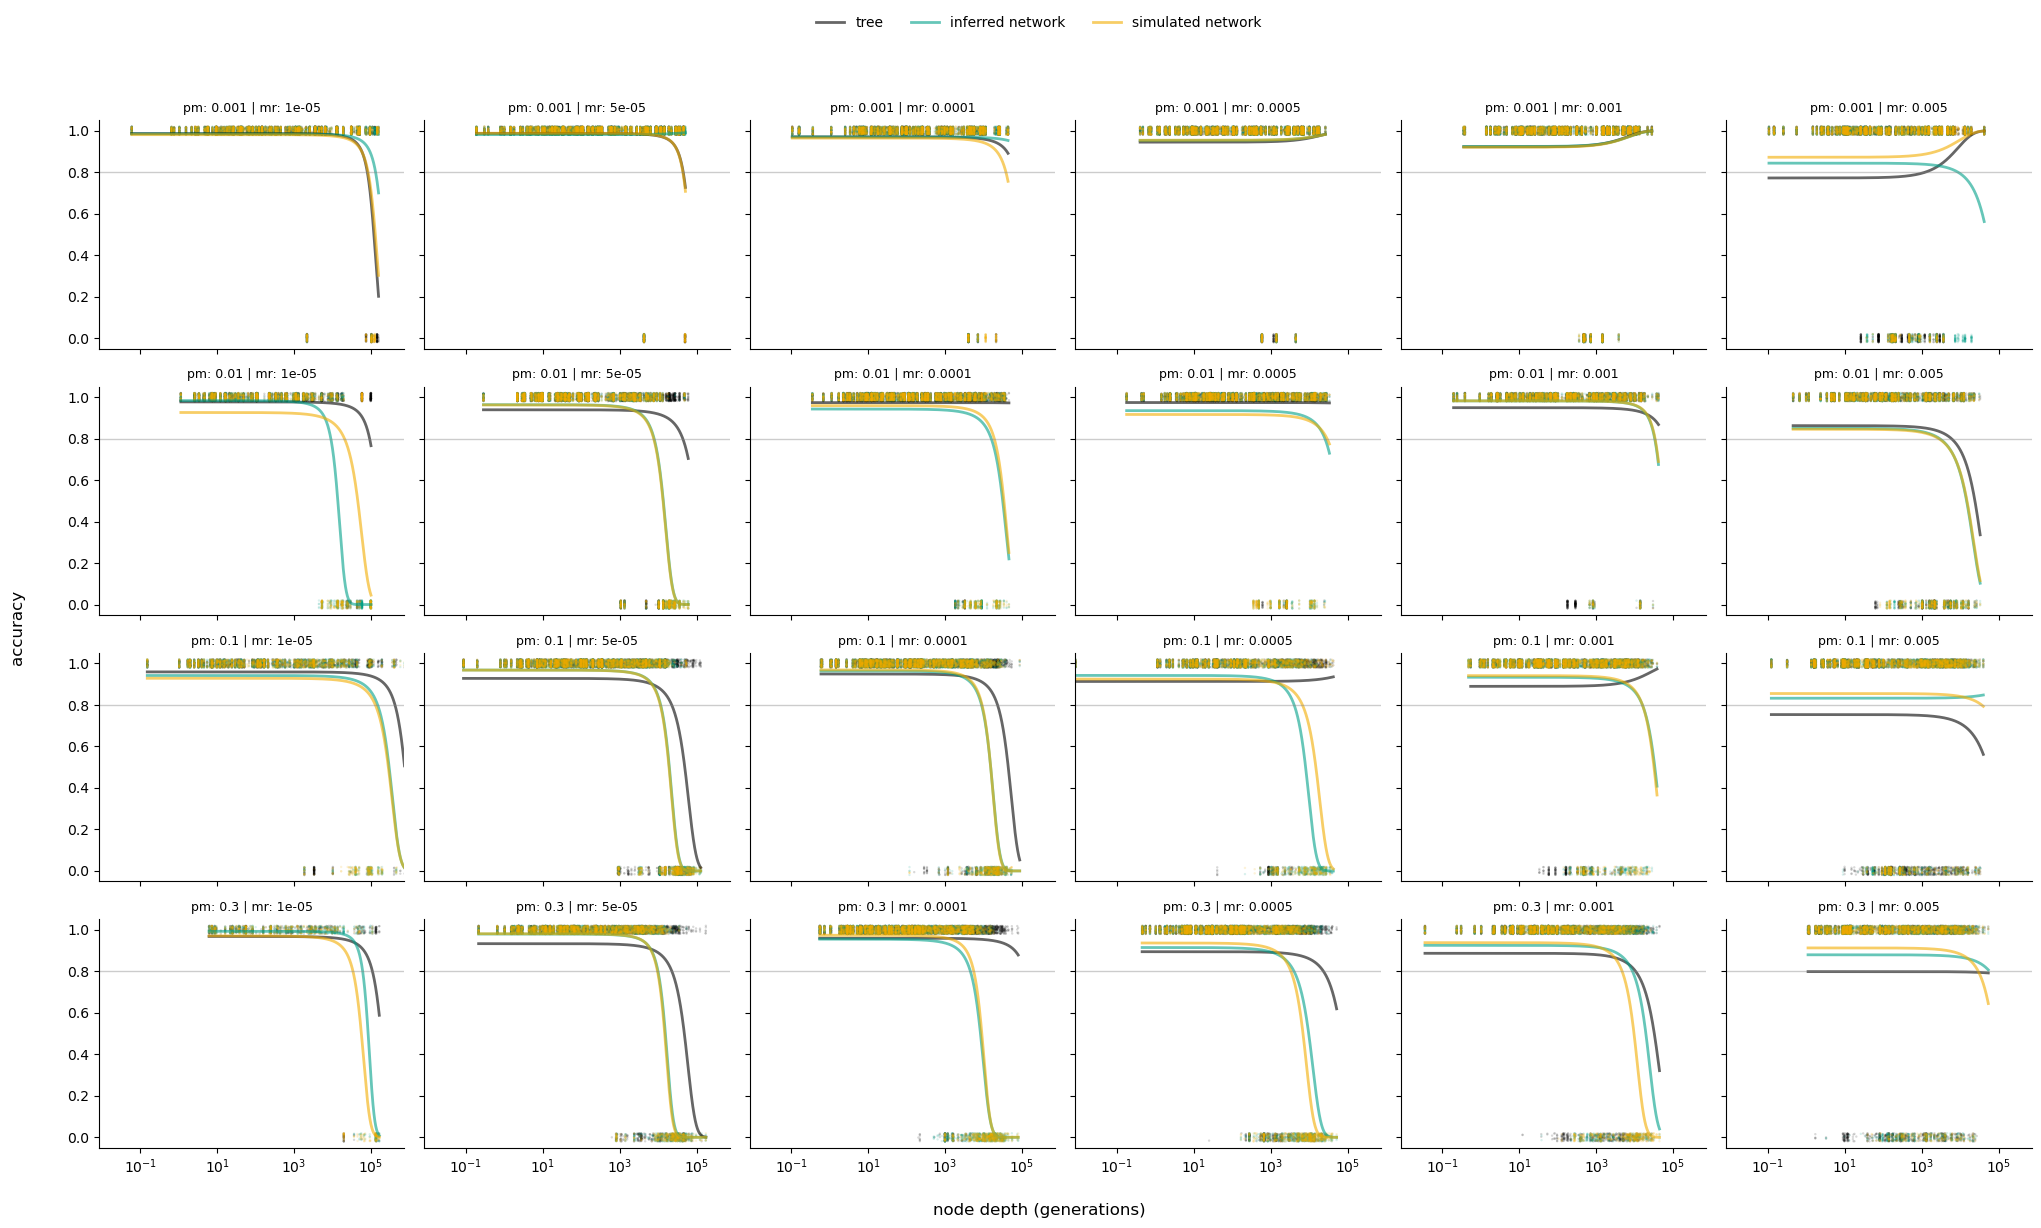

In [15]:
nrows = len(pm_vals)
ncols = len(mr_vals)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3), sharex=True, sharey=True)

# iterate over param combos
for row_idx, pm_val in enumerate(pm_vals):
    for col_idx, mr_val in enumerate(mr_vals):
        ax = axes[row_idx, col_idx]
        
        run_df = downsampled_df[(downsampled_df['pm'] == pm_val) & (downsampled_df['mr'] == mr_val)]
        
        for type_val, type_df in run_df.groupby('type'):
            color = color_palette.get(type_val, "black")

            # plot 0/` scores 
            jittered_y = type_df['score'] + np.random.uniform(-0.02, 0.02, size=len(type_df))
            ax.scatter(
                type_df['node_height_sim'], 
                jittered_y, 
                color=color, 
                alpha=0.15, 
                s=3, 
                edgecolors='none'
            )
            
            # plot glm curve 
            dict_key = (type_val, pm_val, mr_val)
            if dict_key in results_dict:
                preds = results_dict[dict_key]['predictions']
                ax.plot(
                    preds['node_height_sim'], 
                    preds['predicted_score'], 
                    color=color, 
                    linewidth=2.0, 
                    alpha=0.6,
                    label=type_val if (row_idx == 0 and col_idx == 0) else ""
                )

        ax.axhline(y=0.80, color="grey", linestyle="-", alpha=0.4, linewidth=1)
        ax.set_xscale('log')
        ax.set_xlim(downsampled_df['node_height_sim'].min(), downsampled_df['node_height_sim'].max())
        ax.set_ylim(-0.05, 1.05)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.patch.set_facecolor('white')
        
        ax.set_title(f"pm: {pm_val} | mr: {mr_val}", fontsize=9)
        
        # if col_idx == 0:
        #     ax.set_ylabel("accuracy", fontsize=8, color="dimgrey")

fig.text(0.5, 0.01, 'node depth (generations)', ha='center', fontsize=12)
fig.text(0.01, 0.5, 'accuracy', va='center', rotation='vertical', fontsize=12)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, ['tree', 'inferred network', 'simulated network'], loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

plt.tight_layout(rect=[0.03, 0.03, 0.98, 0.95])
plt.show()


## node_height at accuracy 0.8 + glm confidence intervals

In [16]:
results_dict = {}

for (type_val, pm_val, mr_val), type_df in downsampled_df.groupby(['type', 'pm', 'mr']):
    if len(type_df['score'].unique()) < 2:
        continue
        
    model = smf.glm(formula="score ~ node_height_sim", data=type_df, family=sm.families.Binomial())
    fitted_model = model.fit()
    
    max_sim = type_df['node_height_sim'].max()
    min_sim = max(type_df['node_height_sim'].min(), 1e-4)
    
    dense_grid = pd.DataFrame({
        'node_height_sim': np.logspace(np.log10(min_sim), np.log10(max_sim), 500)
    })
    
    # confidence interval bounds 
    pred_obj = fitted_model.get_prediction(dense_grid)
    summary_frame = pred_obj.summary_frame(alpha=0.05)  # 95% CI
    
    dense_grid['predicted_score'] = summary_frame['mean']
    dense_grid['ci_lower'] = summary_frame['mean_ci_lower']
    dense_grid['ci_upper'] = summary_frame['mean_ci_upper']
    
    results_dict[(type_val, pm_val, mr_val)] = {
        'model': fitted_model,
        'predictions': dense_grid
    }

threshold_ci_data = []

for (type_val, pm_val, mr_val), contents in results_dict.items():
    preds = contents['predictions']
    
    # interpolate scores
    def get_crossing_x(y_column_name):
        sub = preds[['node_height_sim', y_column_name]].dropna()
        if len(sub) == 0:
            return np.nan
            
        p_min = sub[y_column_name].min()
        p_max = sub[y_column_name].max()
        max_sim = sub['node_height_sim'].max()
        min_sim = sub['node_height_sim'].min()
        
        # if scores never reach below 0.8, set as max node_height 
        if not (p_min <= 0.8 <= p_max):
            if p_min > 0.8:
                return max_sim
            else:
                return min_sim
                
        # otherwise, identify 0.8 
        sub_sorted = sub.sort_values(by=y_column_name)
        xp = sub_sorted[y_column_name].values
        fp = sub_sorted['node_height_sim'].values
        
        return np.interp(0.8, xp, fp)

    # find 0.8 crossing point 
    x_mean = get_crossing_x('predicted_score')
    x_bound1 = get_crossing_x('ci_lower')
    x_bound2 = get_crossing_x('ci_upper')
    
    # make sure there's a mean b/w lower and upper 
    if not np.isnan(x_mean):
        x_lower = min(x_bound1, x_bound2) if not np.isnan(x_bound1) and not np.isnan(x_bound2) else np.nan
        x_upper = max(x_bound1, x_bound2) if not np.isnan(x_bound1) and not np.isnan(x_bound2) else np.nan
        
        threshold_ci_data.append({
            'type': type_val,
            'pm': pm_val,
            'mr': mr_val,
            'node_height_at_80_lower_ci': x_lower,
            'node_height_at_80_mean': x_mean,
            'node_height_at_80_upper_ci': x_upper
        })

threshold_ci_df = pd.DataFrame(threshold_ci_data)

## score x node_height w/ 95% CI

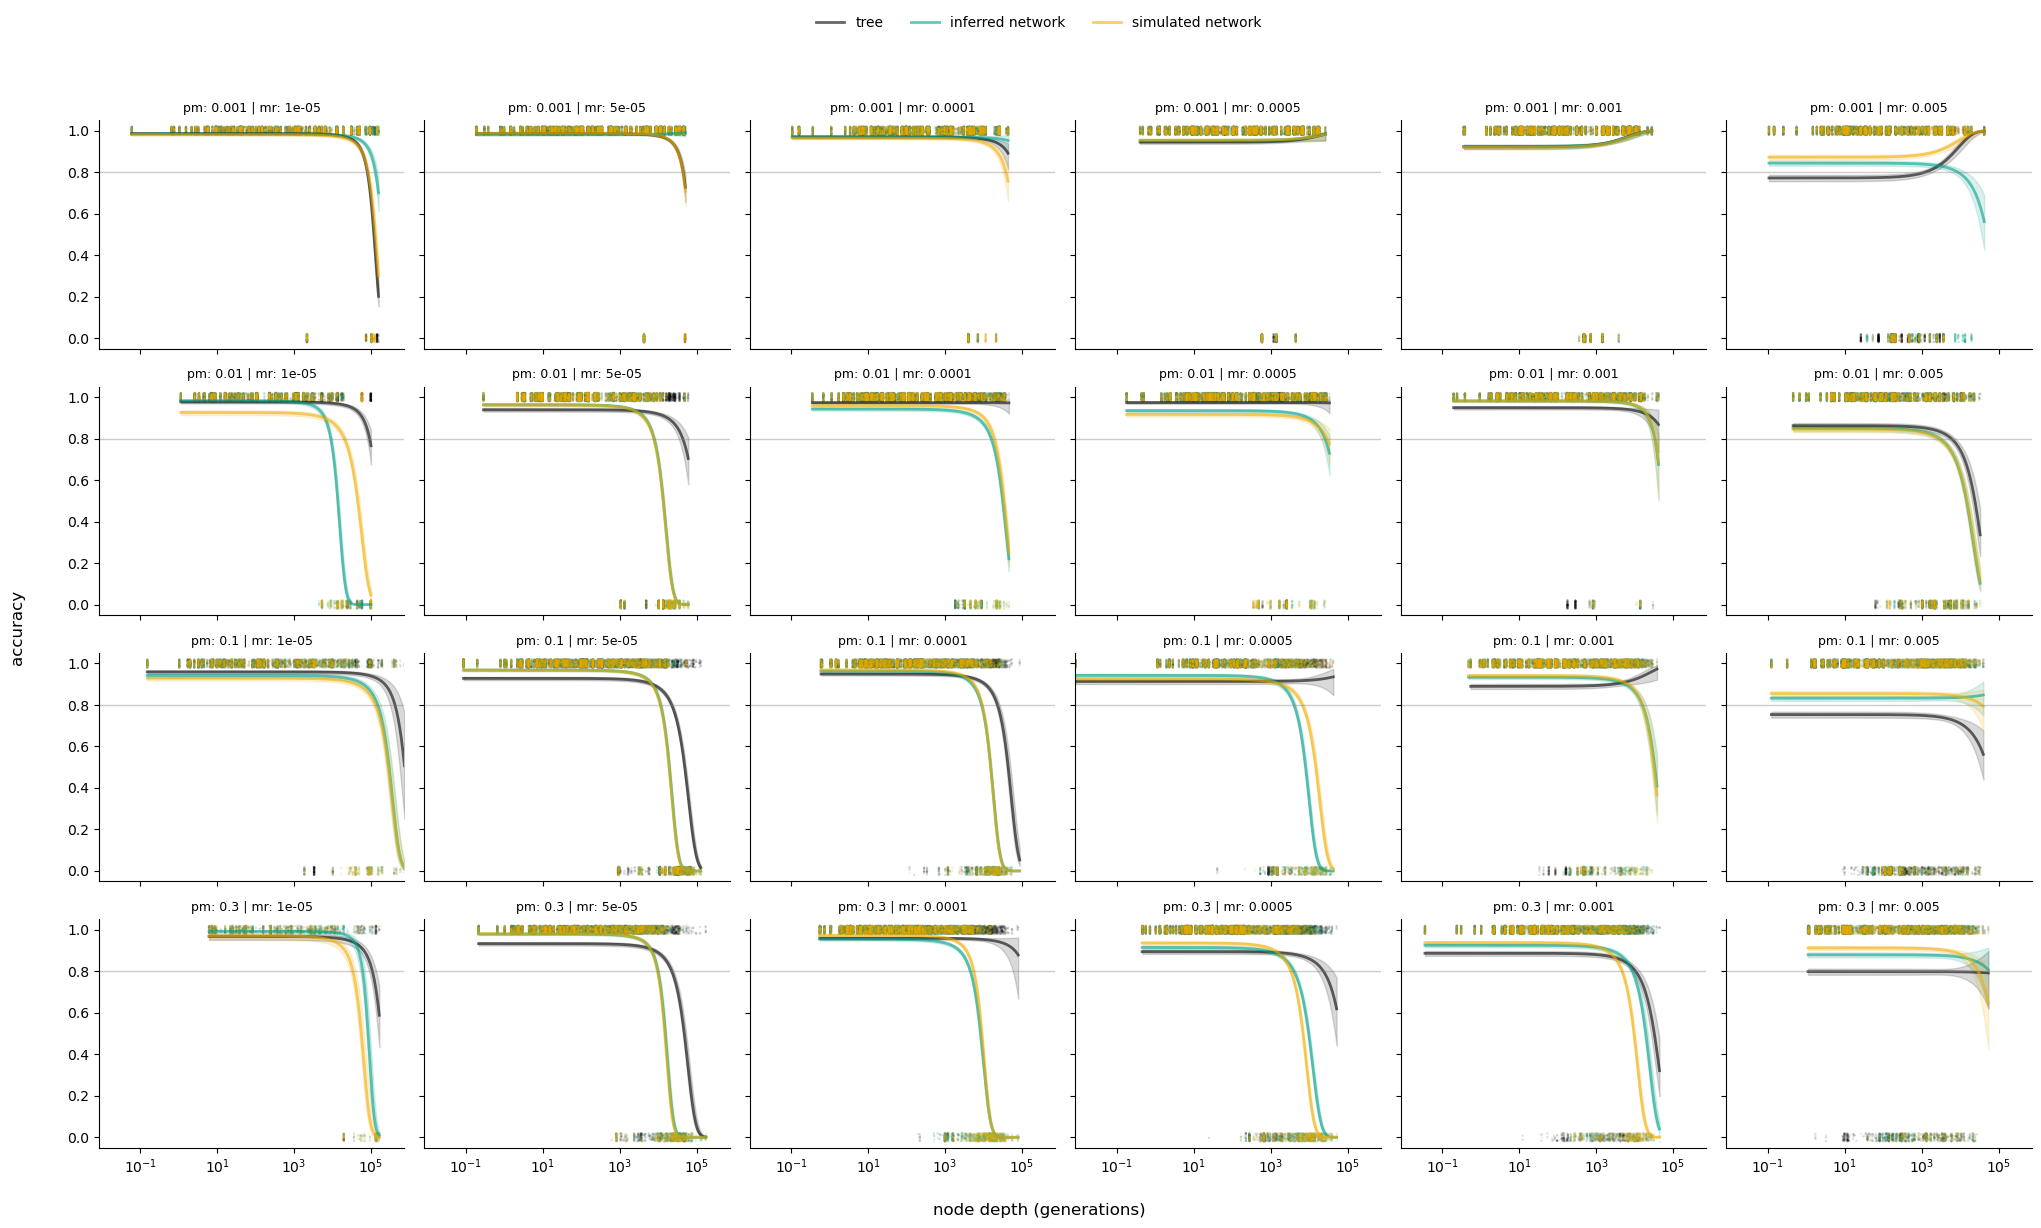

In [17]:
nrows = len(pm_vals)
ncols = len(mr_vals)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3), sharex=True, sharey=True)

for row_idx, pm_val in enumerate(pm_vals):
    for col_idx, mr_val in enumerate(mr_vals):
        ax = axes[row_idx, col_idx]
        
        run_df = downsampled_df[(downsampled_df['pm'] == pm_val) & (downsampled_df['mr'] == mr_val)]
        
        for type_val, type_df in run_df.groupby('type'):
            color = color_palette.get(type_val, "black")
            
            # Scatter raw downsampled points with vertical jittering
            jittered_y = type_df['score'] + np.random.uniform(-0.02, 0.02, size=len(type_df))
            ax.scatter(
                type_df['node_height_sim'], jittered_y, 
                color=color, alpha=0.12, s=3, edgecolors='none'
            )
            
            dict_key = (type_val, pm_val, mr_val)
            if dict_key in results_dict:
                preds = results_dict[dict_key]['predictions']
                
                # Plot central GLM line
                ax.plot(
                    preds['node_height_sim'], preds['predicted_score'], 
                    color=color, linewidth=2.0, alpha=0.6,
                    label=type_val if (row_idx == 0 and col_idx == 0) else ""
                )
                
                # REPLICATES GEOM_RIBBON: Fill area between lower and upper confidence limits
                ax.fill_between(
                    preds['node_height_sim'], 
                    preds['ci_lower'], 
                    preds['ci_upper'], 
                    color=color, 
                    alpha=0.15
                )

        ax.axhline(y=0.80, color="grey", linestyle="-", alpha=0.4, linewidth=1)
        ax.set_xscale('log')
        ax.set_xlim(downsampled_df['node_height_sim'].min(), downsampled_df['node_height_sim'].max())
        ax.set_ylim(-0.05, 1.05)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.patch.set_facecolor('white')
        ax.set_title(f"pm: {pm_val} | mr: {mr_val}", fontsize=9)
        
       

fig.text(0.5, 0.01, 'node depth (generations)', ha='center', fontsize=12)
fig.text(0.01, 0.5, 'accuracy', va='center', rotation='vertical', fontsize=12)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, ['tree', 'inferred network', 'simulated network'], loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

plt.tight_layout(rect=[0.03, 0.03, 0.98, 0.95])
plt.show()


## 0.8 threshold crossing for each pm/mr combination

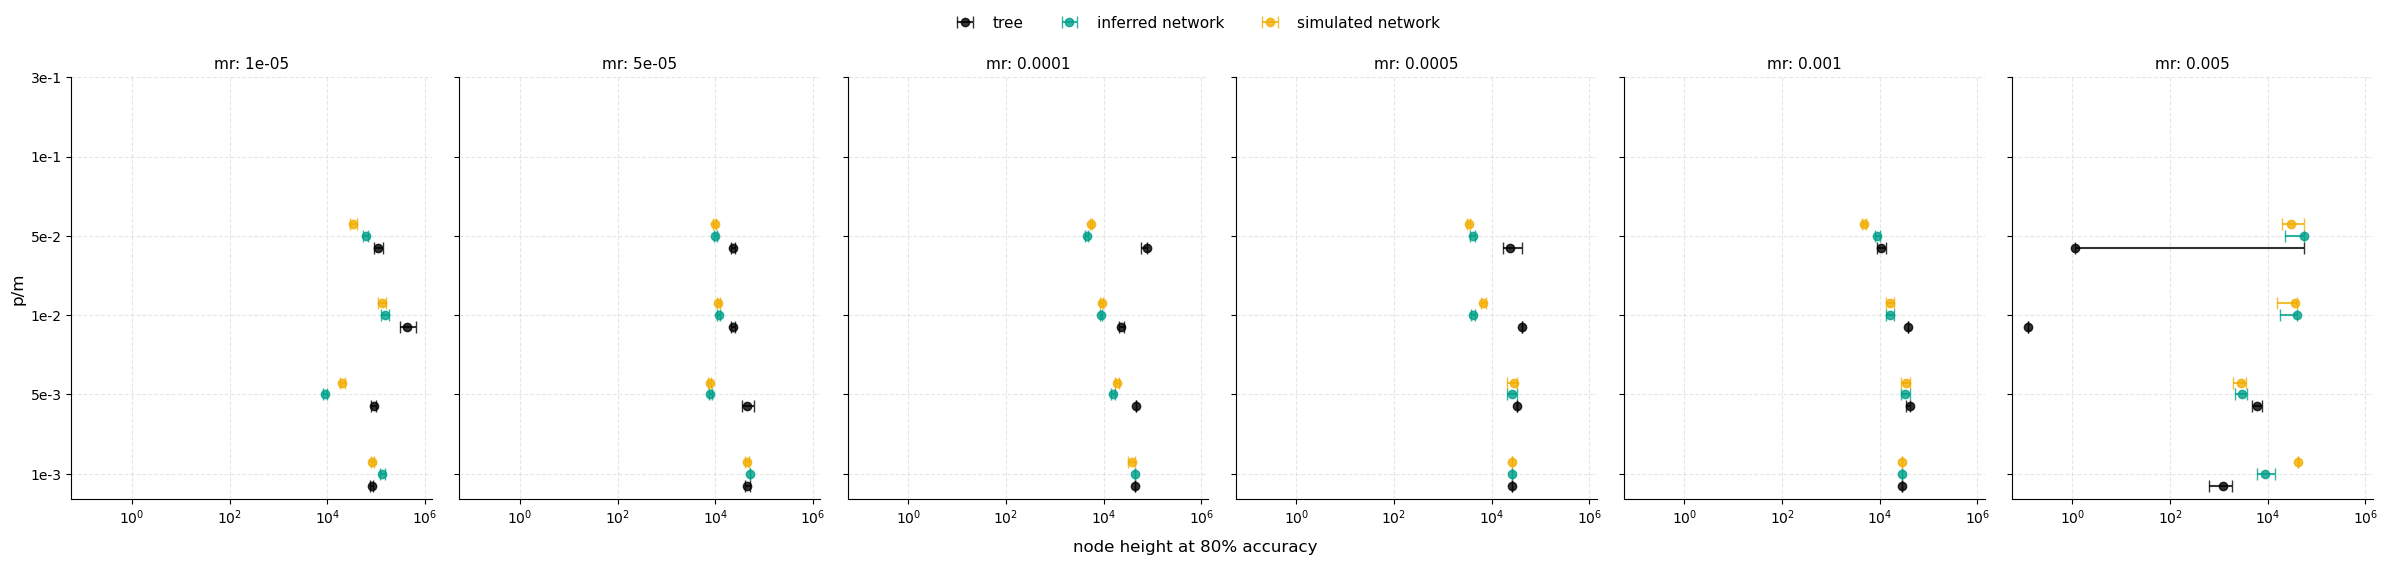

In [18]:
plot_df = threshold_ci_df.dropna(subset=['node_height_at_80_mean']).copy()
plot_df['pm_str'] = plot_df['pm'].astype(str)


# subplots based on unique mr
unique_mrs = mr_vals
ncols = len(unique_mrs)
fig, axes = plt.subplots(1, ncols, figsize=(ncols * 4, 5), sharey=True, sharex=True)

if ncols == 1:
    axes = [axes]

# sorted list of unique pm vals
unique_pms = pm_vals
pm_positions = {val: idx for idx, val in enumerate(unique_pms)}

# plot mr panels 
for idx, mr_val in enumerate(unique_mrs):
    ax = axes[idx]
    mr_df = plot_df[plot_df['mr'] == mr_val]
    
    # group by type 
    for type_val, type_df in mr_df.groupby('type'):
        color = color_palette.get(type_val, "black")
        
        # calculate Y-axis numeric slot positions for each pm value
        y_pos = np.array([pm_positions[p] for p in type_df['pm']])
        
        # Add a subtle vertical offset (dodge) so types don't overlap on the same line
        if type_val == "sim":
            y_pos_dodged = y_pos + 0.15
        elif type_val == "inf":
            y_pos_dodged = y_pos + 0.00
        else:  # ctrl
            y_pos_dodged = y_pos - 0.15
            
        # error bars 
        x_err_left = np.abs(type_df['node_height_at_80_mean'] - type_df['node_height_at_80_lower_ci'])
        x_err_right = np.abs(type_df['node_height_at_80_upper_ci'] - type_df['node_height_at_80_mean'])
        x_errors = np.vstack([x_err_left, x_err_right]) 
        
        # plot markers + error bars
        ax.errorbar(
            x=type_df['node_height_at_80_mean'],
            y=y_pos_dodged,
            xerr=x_errors,
            fmt='o',
            color=color,
            ecolor=color,
            elinewidth=1.5,
            capsize=4,
            markersize=6,
            alpha=0.8,
            label=type_val if idx == 0 else ""  # one legend for entire plot
        )
        
    # fmt
    ax.set_title(f"mr: {mr_val}", fontsize=11)
    ax.set_xscale('log')  # log scale x
    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    
    # theme
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.patch.set_facecolor('white')

# axes
axes[0].set_yticks([0,1,2,3, 4, 5])
axes[0].set_yticklabels(['1e-3', '5e-3', '1e-2', '5e-2','1e-1', '3e-1'])
axes[0].set_ylabel("p/m", fontsize=12)

fig.text(0.5, -0.02, "node height at 80% accuracy", ha='center', fontsize=12)

# legend
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, ['tree', 'inferred network', 'simulated network'], loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


# misc

In [ ]:
# low migration - high migration 
# x axis: recombination rate 
# y axis: node depth 
# facets: node depth at accuracy 0.8 

In [63]:
# merge data
data = [] 
for (pm_val, mr_val), group in runs.groupby(['pm', 'mr']):
    for _, row in group.iterrows():
        csv_df = pd.read_csv(row['path'])
        csv_df['pm'] = pm_val
        csv_df['mr'] = mr_val
        csv_df['seed'] = row['seed']
        csv_df['type'] = row['type']
        data.append(csv_df)

combined_df = pd.concat(data, ignore_index=True)

# categorize mr into low/high
combined_df['migration_strength'] = pd.cut(combined_df['mr'].astype(float), bins=[0, .0002, 1], labels=['low', 'high'])

# downsample
bins = 15
combined_df['node_height_log'] = np.log(combined_df['node_height_sim'])
# combined_df['nh_bin'] = combined_df.groupby(['seed', 'pm', 'mr', 'bin', 'position', 'type'])['node_height_log'].transform(
#     lambda x: pd.cut(x, bins=bins, labels=False))
combined_df['nh_bin'] = pd.cut(combined_df['node_height_log'], bins=bins, labels=False)

downsample_cols = ['seed', 'pm', 'mr', 'migration_strength', 'bin', 'type', 'nh_bin']
downsampled_df = (
    combined_df.groupby(downsample_cols, group_keys=False, dropna=False)
    .apply(lambda x: x.sample(n=min(len(x), 3)))
    .reset_index(drop=True)
)

downsampled_df['mr'] = downsampled_df['mr'].astype(float)
downsampled_df['pm'] = downsampled_df['pm'].astype(float)

# glm
results_dict = {}

# grouped by mr_level and pm 
for (type_val, mr_level_val, pm_val), type_df in downsampled_df.groupby(['type', 'migration_strength', 'pm']):
    if len(type_df['score'].unique()) < 2:
        continue
        
    # fit glm 
    model = smf.glm(formula="score ~ node_height_sim", data=type_df, family=sm.families.Binomial())
    fitted_model = model.fit()
    
    max_sim = type_df['node_height_sim'].max()
    min_sim = max(type_df['node_height_sim'].min(), 1e-4)
    
    dense_grid = pd.DataFrame({
        'node_height_sim': np.logspace(np.log10(min_sim), np.log10(max_sim), 5000)
    })
    dense_grid['predicted_score'] = fitted_model.predict(dense_grid)
    
    # store res
    results_dict[(type_val, mr_level_val, float(pm_val))] = {
        'model': fitted_model,
        'predictions': dense_grid
    }

In [64]:
threshold_data = []

for (type_val, mr_level_val, pm_val), contents in results_dict.items():
    preds = contents['predictions']
    
    def get_crossing_x(y_column_name):
        sub = preds[['node_height_sim', y_column_name]].dropna()
        if len(sub) == 0: return np.nan
        p_min, p_max = sub[y_column_name].min(), sub[y_column_name].max()
        max_sim, min_sim = sub['node_height_sim'].max(), sub['node_height_sim'].min()
        
        # Boundary Clamping Fallback
        if not (p_min <= 0.8 <= p_max):
            return max_sim if p_min > 0.8 else min_sim
                
        sub_sorted = sub.sort_values(by=y_column_name)
        xp = sub_sorted[y_column_name].values
        fp = sub_sorted['node_height_sim'].values
        return np.interp(0.8, xp, fp)

    x_mean = get_crossing_x('predicted_score')
    
    if not np.isnan(x_mean):
        threshold_data.append({
            'type': type_val,
            'migration_strength': mr_level_val,
            'pm': pm_val,
            'node_height_at_80': x_mean
        })

threshold_df = pd.DataFrame(threshold_data)

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/loc/scratch/53633282/ipykernel_29903/1080601596.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


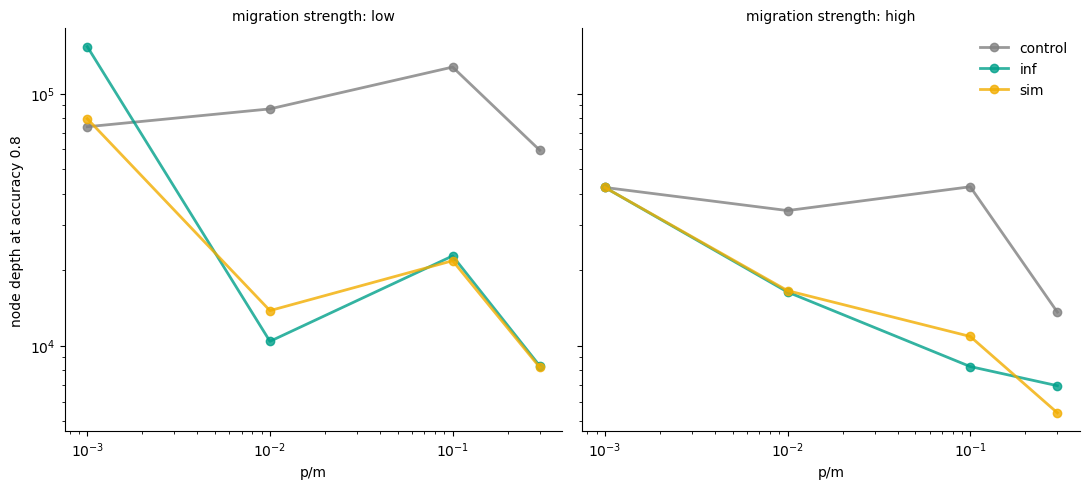

In [65]:
plot_df = threshold_df.sort_values('pm')

color_palette = {
    "sim": "#F2AD00",
    "inf": "#00A08A",
    "control": "grey"
}

# grid w/ one column panel per migration_strength category
g = sns.FacetGrid(
    plot_df, 
    col="migration_strength", 
    hue="type", 
    palette=color_palette, 
    height=5, 
    aspect=1.1,
    col_order=['low', 'high']
)

# trend lines on top of points 
g.map(plt.plot, "pm", "node_height_at_80", marker="o", linewidth=2, alpha=0.8)

# fmt
for ax in g.axes.flat:
    ax.set_yscale('log')  
    ax.set_xscale('log')  
    #ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# fmt titles
g.set_axis_labels("p/m", "node depth at accuracy 0.8")
g.set_titles("migration strength: {col_name}")

# fmt legend 
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(handles, ['tree', 'inferred network', 'simulated network'], loc='best', frameon=False, fontsize=11)
    
plt.tight_layout()
plt.show()

In [66]:
# low migration - high migration 
# x axis: recombination rate 
# y axis: accuracy score 
# facets: node depth at 100 generations; at 1000 generations 



In [67]:
milestone_data = []

for (type_val, mr_level_val, pm_val), contents in results_dict.items():
    preds = contents['predictions'].sort_values('node_height_sim')
    
    # interpolate scores at targets 100,1000,10000
    def get_accuracy_at_depth(target_depth):
        xp = preds['node_height_sim'].values
        fp = preds['predicted_score'].values
        
        # check if depth in bounds
        if xp.min() <= target_depth <= xp.max():
            return np.interp(target_depth, xp, fp)
        elif target_depth < xp.min():
            return fp[0]  # fallback depth 
        else:
            return fp[-1]

    # get scores 
    acc_100 = get_accuracy_at_depth(100)
    acc_1000 = get_accuracy_at_depth(1000)
    acc_10000 = get_accuracy_at_depth(10000)
    
    # append to res
    milestone_data.append({
        'type': type_val,
        'migration_strength': mr_level_val,
        'pm': pm_val,
        'depth_milestone': '100 generations',
        'accuracy_score': acc_100
    })
    milestone_data.append({
        'type': type_val,
        'migration_strength': mr_level_val,
        'pm': pm_val,
        'depth_milestone': '1000 generations',
        'accuracy_score': acc_1000
    })
    milestone_data.append({
        'type': type_val,
        'migration_strength': mr_level_val,
        'pm': pm_val,
        'depth_milestone': '10000 generations',
        'accuracy_score': acc_10000
    })

milestone_df = pd.DataFrame(milestone_data)


In [68]:
milestone_df['pm'] = pd.to_numeric(milestone_df['pm'])

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/loc/scratch/53633282/ipykernel_29903/2435663783.py:43: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


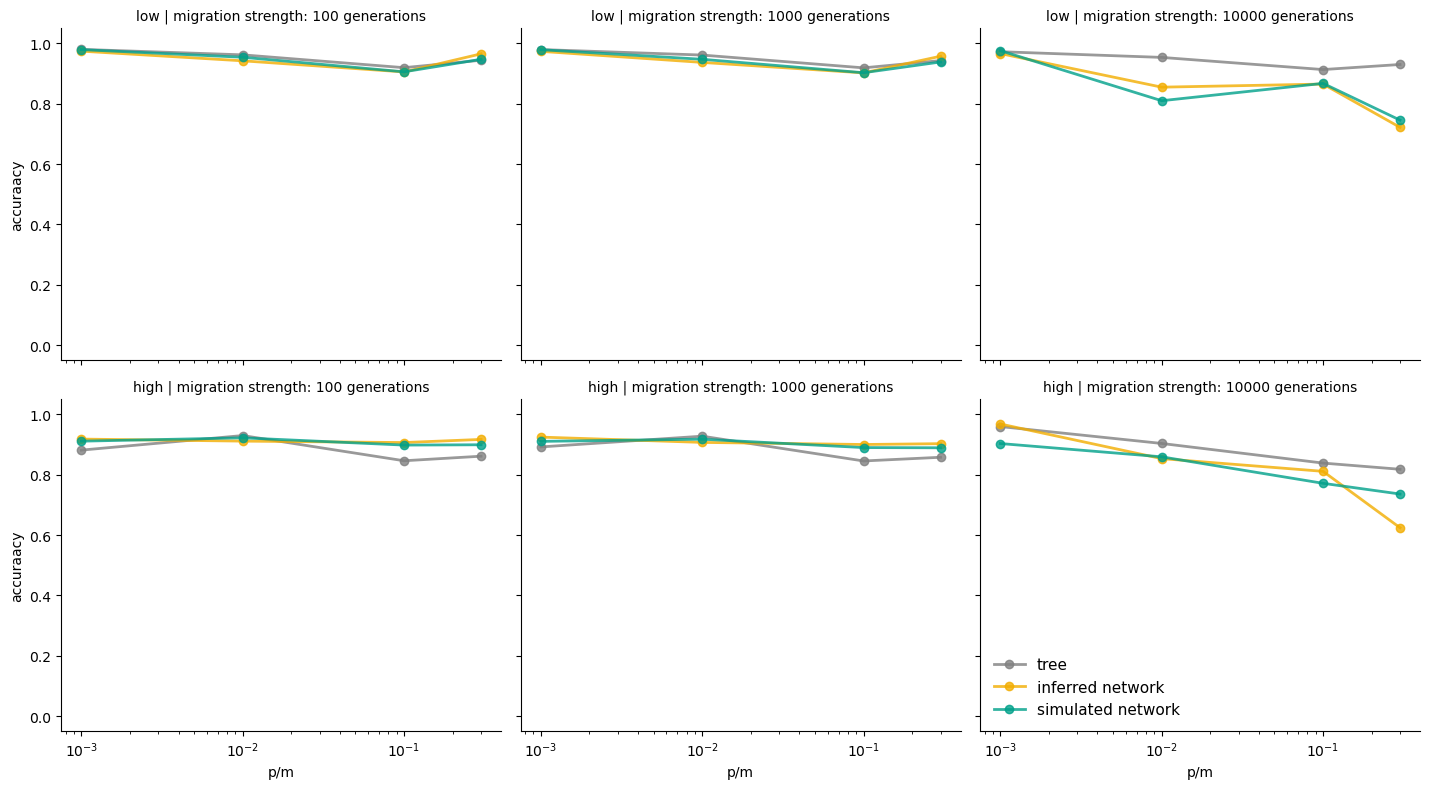

In [72]:
# sort pm 
plot_df = milestone_df.sort_values('pm')

color_palette = {
    "sim": "#F2AD00",
    "inf": "#00A08A",
    "control": "grey"
}

# plot 
g = sns.FacetGrid(
    plot_df, 
    col="depth_milestone", 
    row="migration_strength", 
    hue="type", 
    palette=color_palette, 
    height=4, 
    aspect=1.2,
    row_order=['low', 'high'],
    col_order=['100 generations', '1000 generations', '10000 generations']
)

# plot trend lines 
g.map(plt.plot, "pm", "accuracy_score", marker="o", linewidth=2, alpha=0.8)

# fmt axes 
for ax in g.axes.flat:
    ax.set_xscale('log')  
    ax.set_ylim(-0.05, 1.05)  
   # ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# fmt title
g.set_axis_labels("p/m", "accuraacy")
g.set_titles(row_template="{row_name}", col_template="migration strength: {col_name}")

# fmt legend 
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(handles, ['tree', 'inferred network', 'simulated network'], loc='best', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()


In [73]:
threshold_ci_df['mr'] = threshold_ci_df['mr'].astype(float)
threshold_ci_df['pm'] = threshold_ci_df['pm'].astype(float)

### quick heatmaps

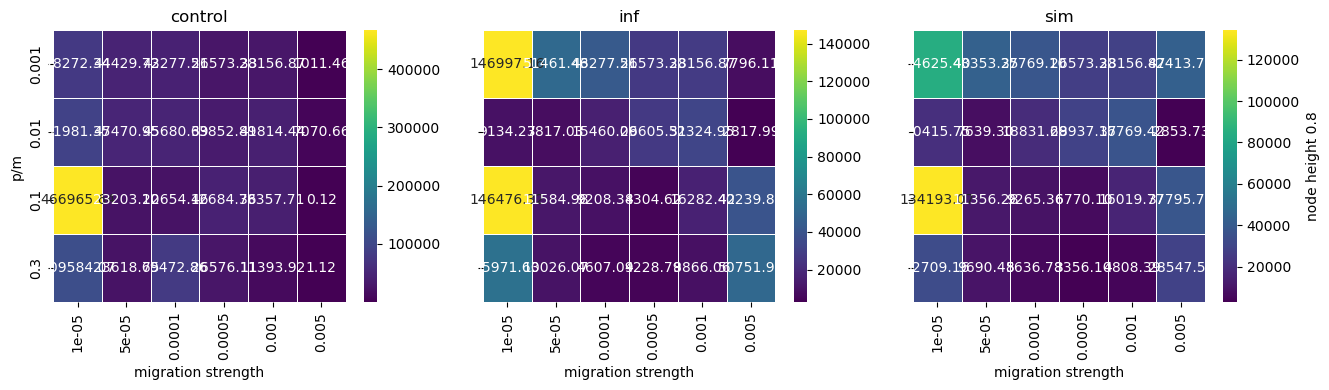

In [74]:

unique_types = threshold_ci_df['type'].unique()
fig, axes = plt.subplots(1, len(unique_types), figsize=(len(unique_types) * 4.5, 4), sharey=True)

if len(unique_types) == 1:
    axes = [axes]

for idx, type_val in enumerate(unique_types):
    ax = axes[idx]
    type_df = threshold_ci_df[threshold_ci_df['type'] == type_val]
    
    # rows = pm, columns = mr
    matrix = type_df.pivot(index='pm', columns='mr', values='node_height_at_80_mean')
   # matrix = matrix.sort_index(ascending=False)
    
    sns.heatmap(
        matrix, 
        ax=ax, 
        cmap="viridis", 
        annot=True, 
        fmt=".2f", 
        cbar_kws={'label': 'node height 0.8'} if idx == len(unique_types)-1 else None,
        linewidths=0.5
    )
    ax.set_title(f"{type_val}")
    ax.set_xlabel("migration strength")
    if idx == 0:
        ax.set_ylabel("p/m")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()


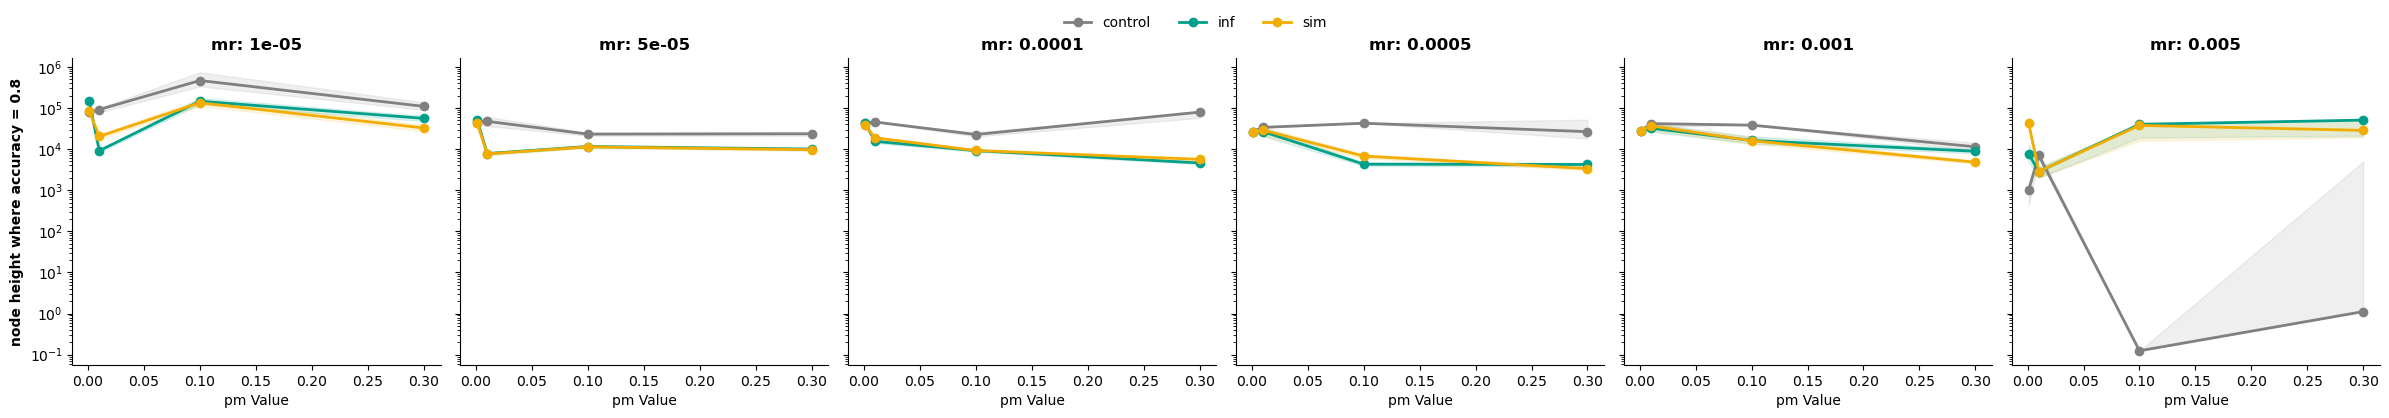

In [75]:
unique_mrs = sorted(threshold_ci_df['mr'].unique())
ncols = len(unique_mrs)
fig, axes = plt.subplots(1, ncols, figsize=(ncols * 4, 4), sharey=True)
if ncols == 1: axes = [axes]

color_palette = {"sim": "#F2AD00", "inf": "#00A08A", "control": "grey"}

for idx, mr_val in enumerate(unique_mrs):
    ax = axes[idx]
    mr_df = threshold_ci_df[threshold_ci_df['mr'] == mr_val].sort_values('pm')
    
    for type_val, type_df in mr_df.groupby('type'):
        color = color_palette.get(type_val, "black")
        
        # trend lines
        ax.plot(
            type_df['pm'], 
            type_df['node_height_at_80_mean'], 
            marker='o', 
            color=color, 
            linewidth=2, 
            label=type_val if idx == 0 else ""
        )
        
        # uncertainty
        ax.fill_between(
            type_df['pm'], 
            type_df['node_height_at_80_lower_ci'], 
            type_df['node_height_at_80_upper_ci'], 
            color=color, 
            alpha=0.12
        )
        
    ax.set_title(f"mr: {mr_val}", fontweight="bold")
    ax.set_xlabel("p/m")
    ax.set_yscale('log') 
    if idx == 0:
        ax.set_ylabel("node depth where accuracy = 0.8")
        
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False)

plt.tight_layout()
plt.show()


/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


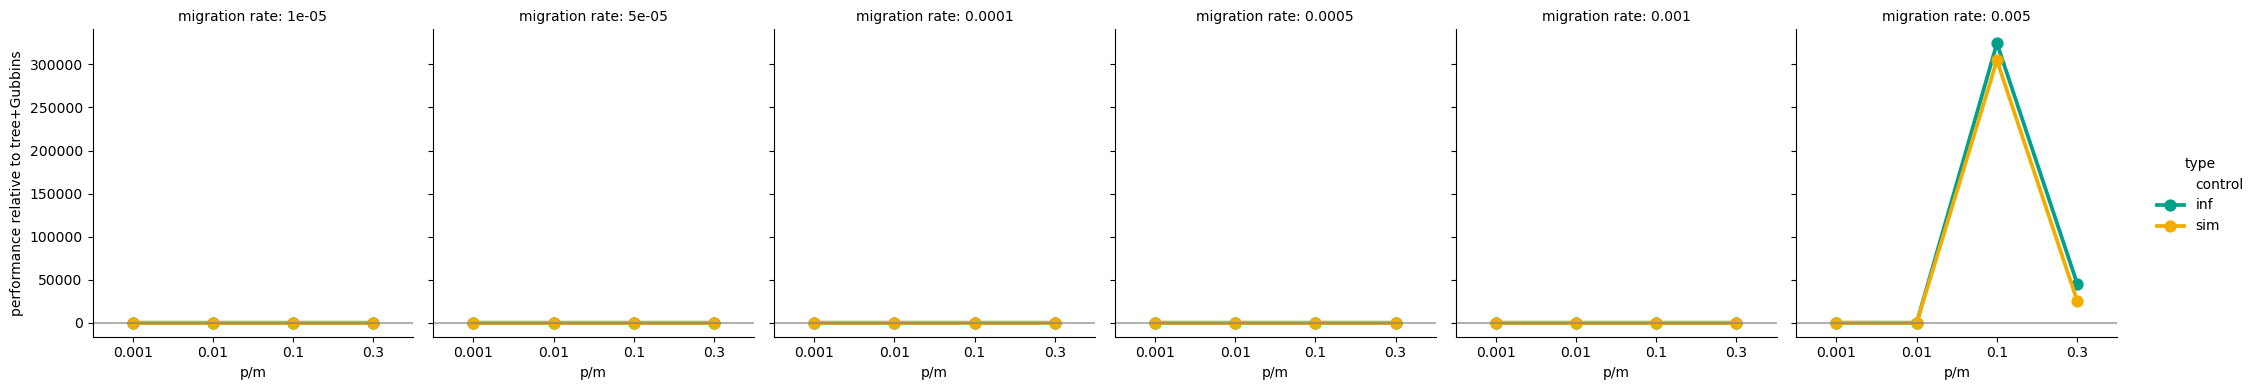

In [76]:
# use control as benchmark 
ctrl_df = threshold_ci_df[threshold_ci_df['type'] == 'control'][['pm', 'mr', 'node_height_at_80_mean']].rename(
    columns={'node_height_at_80_mean': 'ctrl_mean'}
)

# calculate ratios relative to the control baseline performance
ratio_df = threshold_ci_df[threshold_ci_df['type'] != 'ctrl'].merge(ctrl_df, on=['pm', 'mr'], how='left')
ratio_df['performance_ratio'] = ratio_df['node_height_at_80_mean'] / ratio_df['ctrl_mean']

# plot
g = sns.catplot(
    data=ratio_df, 
    x='pm', 
    y='performance_ratio', 
    hue='type', 
    col='mr', 
    kind='point',
    palette={"sim": "#F2AD00", "inf": "#00A08A", "control":"none"},
    height=4, 
    aspect=0.9
)

# draw line for baseline 
g.map(plt.axhline, y=1.0, color='grey', linestyle='-', alpha=0.6, linewidth=1.5)

g.set_axis_labels("p/m", "performance relative to tree+Gubbins")
g.set_titles("migration rate: {col_name}")
plt.show()


results are kind of extreme looking because threshold_val is high for runs where accuracy never drops below 0.8

/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
/app/software/Seaborn/0.13.2-gfbf-2023a/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


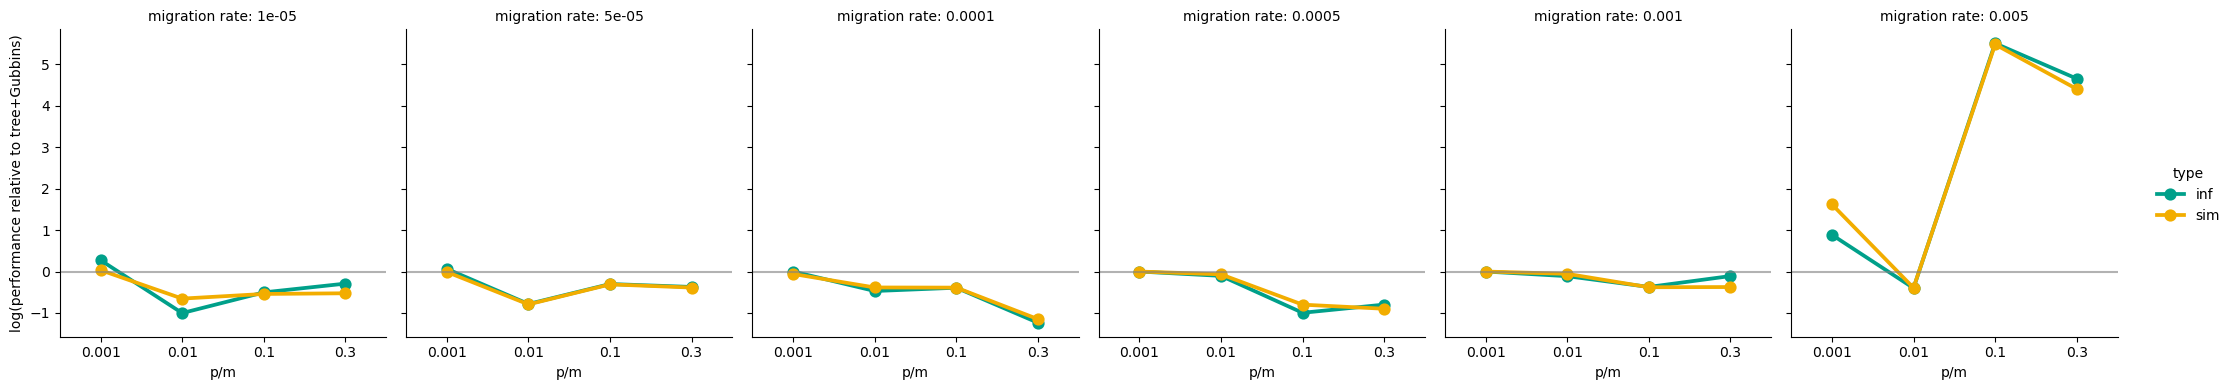

In [77]:
ctrl_df = threshold_ci_df[threshold_ci_df['type'] == 'control'][['pm', 'mr', 'node_height_at_80_mean']].rename(
    columns={'node_height_at_80_mean': 'ctrl_mean'}
)

ratio_df = threshold_ci_df[threshold_ci_df['type'] != 'control'].merge(ctrl_df, on=['pm', 'mr'], how='left')

# do log fold change instead
ratio_df['log_performance_ratio'] = np.log10(ratio_df['node_height_at_80_mean'] / ratio_df['ctrl_mean'])

# plot
g = sns.catplot(
    data=ratio_df, 
    x='pm', 
    y='log_performance_ratio', 
    hue='type', 
    col='mr', 
    kind='point',
    palette={"sim": "#F2AD00", "inf": "#00A08A"},
    height=4, 
    aspect=0.9
)

# draw baseline at 0 (log10(1.0) 
g.map(plt.axhline, y=0.0, color='grey', linestyle='-', alpha=0.6, linewidth=1.5)

g.set_axis_labels("p/m", "log(performance relative to tree+Gubbins)")
g.set_titles("migration rate: {col_name}")

plt.show()


# re-categorize mr as low vs high? 

In [24]:
# merge data
data = [] 
for (pm_val, mr_val), group in runs.groupby(['pm', 'mr']):
    for _, row in group.iterrows():
        csv_df = pd.read_csv(row['path'])
        csv_df['pm'] = pm_val
        csv_df['mr'] = mr_val
        csv_df['seed'] = row['seed']
        csv_df['type'] = row['type']
        data.append(csv_df)

combined_df = pd.concat(data, ignore_index=True)

# categorize mr into low/high
combined_df['mr_level'] = pd.cut(combined_df['mr'].astype(float), bins=[0, 1e-4, 1], labels=['low', 'high'])

# downsample
bins = 10
combined_df['node_height_log'] = np.log(combined_df['node_height_sim'])
combined_df['nh_bin'] = combined_df.groupby(['seed', 'pm', 'mr', 'bin', 'position', 'type'])['node_height_log'].transform(
    lambda x: pd.cut(x, bins=bins, labels=False))


downsample_cols = ['seed', 'pm', 'mr', 'mr_level', 'bin', 'type', 'nh_bin']
downsampled_df = (
    combined_df.groupby(downsample_cols, group_keys=False, dropna=False)
    .apply(lambda x: x.sample(n=min(len(x), 3)))
    .reset_index(drop=True)
)

downsampled_df['mr'] = downsampled_df['mr'].astype(float)
downsampled_df['pm'] = downsampled_df['pm'].astype(float)

# glm
results_dict = {}

# grouped by mr_level and pm 
for (type_val, mr_level_val, pm_val), type_df in downsampled_df.groupby(['type', 'mr_level', 'pm']):
    if len(type_df['score'].unique()) < 2:
        continue
        
    # fit glm 
    model = smf.glm(formula="score ~ node_height_sim", data=type_df, family=sm.families.Binomial())
    fitted_model = model.fit()
    
    max_sim = type_df['node_height_sim'].max()
    min_sim = max(type_df['node_height_sim'].min(), 1e-4)
    
    dense_grid = pd.DataFrame({
        'node_height_sim': np.logspace(np.log10(min_sim), np.log10(max_sim), 500)
    })
    dense_grid['predicted_score'] = fitted_model.predict(dense_grid)
    
    # store res
    results_dict[(type_val, mr_level_val, float(pm_val))] = {
        'model': fitted_model,
        'predictions': dense_grid
    }


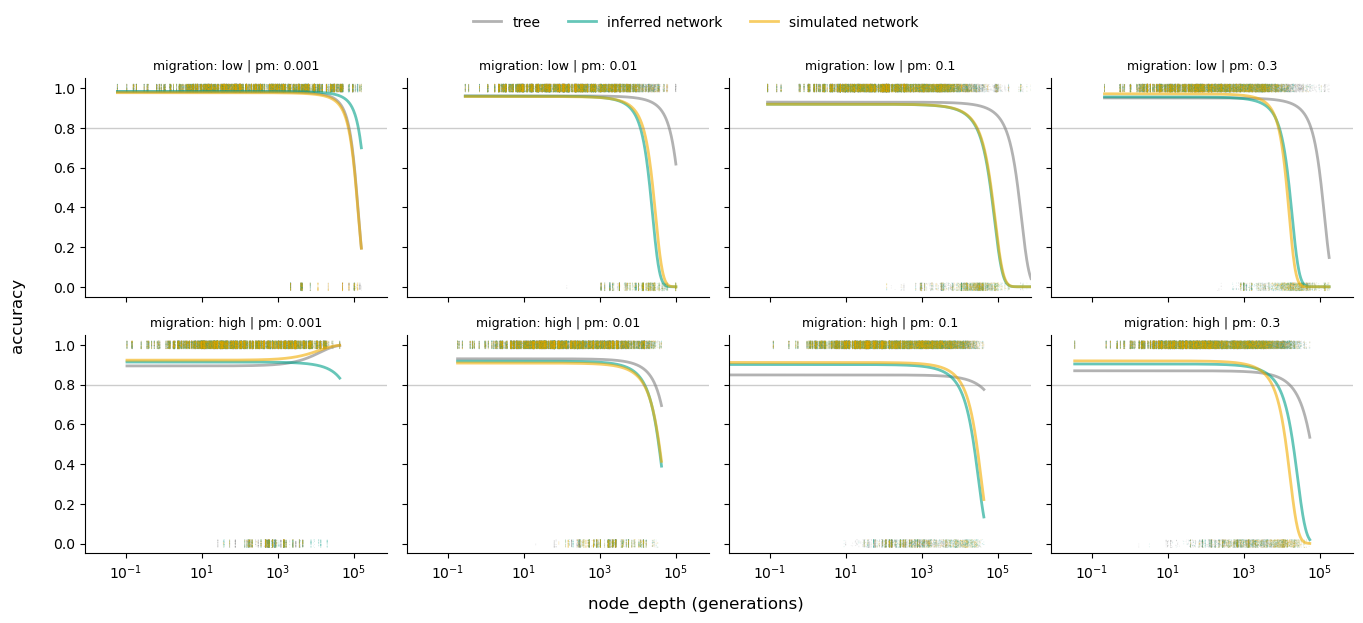

In [26]:
mr_levels = ['low', 'high']

nrows = len(mr_levels)
ncols = len(pm_vals)  

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3), sharex=True, sharey=True)

for row_idx, mr_level_val in enumerate(mr_levels):
    for col_idx, pm_val in enumerate(pm_vals):
        ax = axes[row_idx, col_idx]
        
        # subset to mr_level/pm
        run_df = downsampled_df[(downsampled_df['mr_level'] == mr_level_val) & (downsampled_df['pm'] == pm_val)]
        
        for type_val, type_df in run_df.groupby('type'):
            color = color_palette.get(type_val, "black")
            
            jittered_y = type_df['score'] + np.random.uniform(-0.02, 0.02, size=len(type_df))
            ax.scatter(
                type_df['node_height_sim'], jittered_y, 
                color=color, alpha=0.15, s=0.5, edgecolors='none'
            )
            
            # parse dic
            dict_key = (type_val, mr_level_val, pm_val)
            if dict_key in results_dict:
                preds = results_dict[dict_key]['predictions']
                ax.plot(
                    preds['node_height_sim'], preds['predicted_score'], 
                    color=color, linewidth=2.0, alpha=0.6,
                    label=type_val if (row_idx == 0 and col_idx == 0) else ""
                )

        ax.axhline(y=0.80, color="grey", linestyle="-", alpha=0.4, linewidth=1)
        ax.set_xscale('log')
        ax.set_xlim(downsampled_df['node_height_sim'].min(), downsampled_df['node_height_sim'].max())
        ax.set_ylim(-0.05, 1.05)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.patch.set_facecolor('white')
        
        ax.set_title(f"migration: {mr_level_val} | pm: {pm_val}", fontsize=9)
        

fig.text(0.5, 0.01, 'node depth (generations)', ha='center', fontsize=12)
fig.text(0.01, 0.5, 'accuracy', va='center', rotation='vertical', fontsize=12)

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, ['tree', 'inferred network', 'simulated network'], loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

plt.tight_layout(rect=[0.03, 0.03, 0.98, 0.95])
plt.show()
